# Data Processing

In [ ]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split

# 1. Load the dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Combine train and test sets for custom splitting (70/15/15)
x = np.concatenate([x_train, x_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

# 2. Normalize pixel values to [0, 1]
x = x.astype('float32') / 255.0

# 3. Flatten images to 1D vectors (28x28 = 784) for non-NN models
x_flattened = x.reshape(x.shape[0], -1)  # Shape: (70000, 784)

# 4. Split the data: 70% train, 15% validation, 15% test
x_temp, x_test_final, y_temp, y_test_final = train_test_split(
    x_flattened, y, test_size=0.15, random_state=42, stratify=y)

x_train_final, x_val_final, y_train_final, y_val_final = train_test_split(
    x_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)  # 0.1765 * 85% ≈ 15%

# Final shapes check
print(f"Train: {x_train_final.shape}, Validation: {x_val_final.shape}, Test: {x_test_final.shape}")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (48998, 784), Validation: (10502, 784), Test: (10500, 784)


# Dimensionality Reduction with PCA

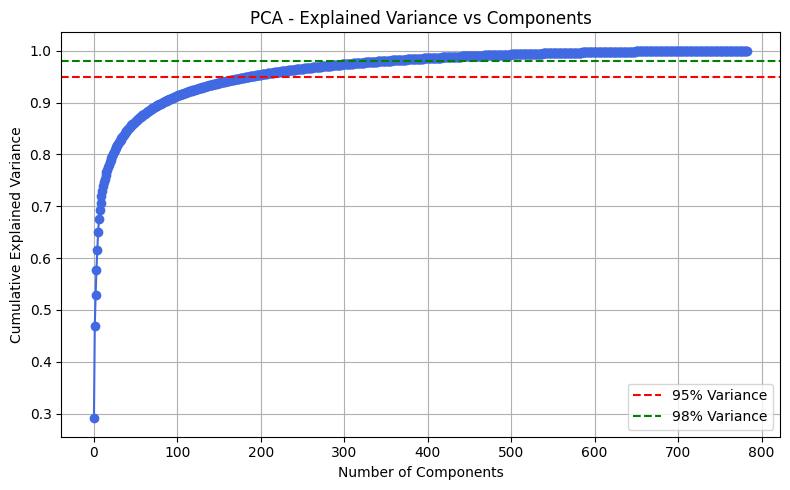

Components for 95% variance: 187
Components for 98% variance: 348


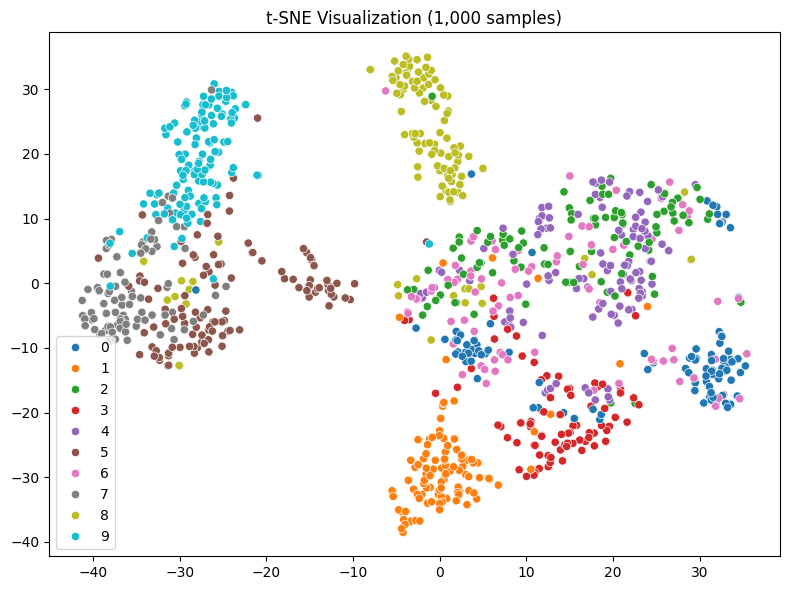

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP output shape (train): (48998, 50)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

# Use the flattened, normalized training/validation/test sets from Step 1
# x_train_final, x_val_final, x_test_final, y_train_final, y_val_final, y_test_final

# ---------- PCA ----------
# 1. Fit PCA on training data
pca = PCA()
pca.fit(x_train_final)

# 2. Plot cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o', color='royalblue')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance vs Components")
plt.axhline(y=0.95, color='r', linestyle='--', label="95% Variance")
plt.axhline(y=0.98, color='g', linestyle='--', label="98% Variance")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Choose components for 95% and 98% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_98 = np.argmax(cumulative_variance >= 0.98) + 1

print(f"Components for 95% variance: {n_components_95}")
print(f"Components for 98% variance: {n_components_98}")

# 4. Apply PCA transformation
pca_95 = PCA(n_components=n_components_95)
x_train_pca95 = pca_95.fit_transform(x_train_final)
x_val_pca95 = pca_95.transform(x_val_final)
x_test_pca95 = pca_95.transform(x_test_final)

pca_98 = PCA(n_components=n_components_98)
x_train_pca98 = pca_98.fit_transform(x_train_final)
x_val_pca98 = pca_98.transform(x_val_final)
x_test_pca98 = pca_98.transform(x_test_final)

# ---------- t-SNE ----------
# Visualize first 1,000 samples of training set
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
x_train_tsne = tsne.fit_transform(x_train_final[:1000])

plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_train_tsne[:, 0], y=x_train_tsne[:, 1],
                hue=y_train_final[:1000], palette='tab10', legend='full')
plt.title("t-SNE Visualization (1,000 samples)")
plt.tight_layout()
plt.show()

# ---------- UMAP ----------
# Reduce to 50 dimensions
umap_model = umap.UMAP(n_components=50, random_state=42)
x_train_umap = umap_model.fit_transform(x_train_final)
x_val_umap = umap_model.transform(x_val_final)
x_test_umap = umap_model.transform(x_test_final)

print(f"UMAP output shape (train): {x_train_umap.shape}")


# Model Selection and Regularization Techniques

### Imports

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import tensorflow as tf


In [ ]:
# PCA transformation for model training
from sklearn.decomposition import PCA

# Keep 95% variance
pca = PCA(n_components=0.95)
pca.fit(x_train_final)

# Transform train, val, and test sets
x_train_pca = pca.transform(x_train_final)
x_val_pca = pca.transform(x_val_final)
x_test_pca = pca.transform(x_test_final)

print(f"x_train_pca shape: {x_train_pca.shape}")
print(f"Number of PCA components: {pca.n_components_}")
print(f"Total variance retained: {sum(pca.explained_variance_ratio_):.2f}")



x_train_pca shape: (48998, 187)
Number of PCA components: 187
Total variance retained: 0.95


### 1.Baseline Neural Network (L2 +Dropout)

In [ ]:
def overfitting_gap(history, l2_lambda, dropout_rate_1, dropout_rate_2):
    # Plot
    # Calculate Overfitting Gap (Training vs Validation Accuracy)
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    # Calculate the gap
    overfitting_gap = [train_accuracy[i] - val_accuracy[i] for i in range(len(train_accuracy))]

    # Print or plot the overfitting gap
    print(f"Overfitting Gap (Training Accuracy - Validation Accuracy): {overfitting_gap[-1]}")

    # Optional: Plot the overfitting gap across epochs
    plt.plot(overfitting_gap)
    plt.title(f"Overfitting Gap (L2={l2_lambda}, Dropout={dropout_rate_1},{dropout_rate_2})")
    plt.xlabel('Epochs')
    plt.ylabel('Overfitting Gap (Training Accuracy - Validation Accuracy)')
    plt.show()

In [ ]:
def plot_loss_curves(history):
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


Epoch 1/50
383/383 - 5s - 14ms/step - accuracy: 0.7986 - loss: 0.5793 - val_accuracy: 0.8480 - val_loss: 0.4329
Epoch 2/50
383/383 - 2s - 6ms/step - accuracy: 0.8534 - loss: 0.4117 - val_accuracy: 0.8605 - val_loss: 0.3927
Epoch 3/50
383/383 - 4s - 10ms/step - accuracy: 0.8693 - loss: 0.3629 - val_accuracy: 0.8644 - val_loss: 0.3795
Epoch 4/50
383/383 - 4s - 9ms/step - accuracy: 0.8786 - loss: 0.3346 - val_accuracy: 0.8760 - val_loss: 0.3397
Epoch 5/50
383/383 - 2s - 6ms/step - accuracy: 0.8848 - loss: 0.3150 - val_accuracy: 0.8823 - val_loss: 0.3287
Epoch 6/50
383/383 - 2s - 6ms/step - accuracy: 0.8901 - loss: 0.3002 - val_accuracy: 0.8866 - val_loss: 0.3135
Epoch 7/50
383/383 - 3s - 8ms/step - accuracy: 0.8921 - loss: 0.2895 - val_accuracy: 0.8745 - val_loss: 0.3354
Epoch 8/50
383/383 - 3s - 8ms/step - accuracy: 0.8981 - loss: 0.2755 - val_accuracy: 0.8860 - val_loss: 0.3123
Epoch 9/50
383/383 - 6s - 15ms/step - accuracy: 0.9009 - loss: 0.2685 - val_accuracy: 0.8792 - val_loss: 0.333

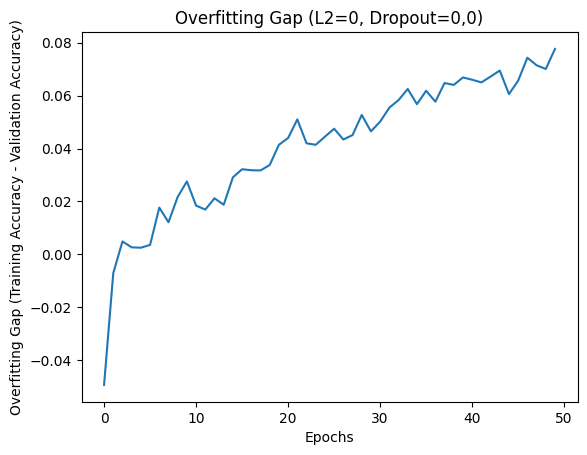

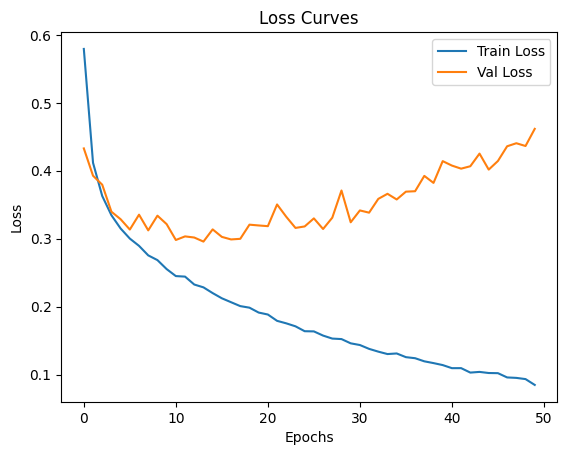

In [ ]:
def build_nn(input_dim, is_pca=False, l2_lambda=0.001, dropout_rate_1=0.2, dropout_rate_2=0.5):

    model = Sequential()

    # First Dense layer with L2 regularization
    model.add(Dense(128, activation='relu', input_shape=(input_dim,), kernel_regularizer=regularizers.l2(l2_lambda)))
    model.add(Dropout(dropout_rate_1))

    # Second Dense layer with L2 regularization
    model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_lambda)))
    model.add(Dropout(dropout_rate_2))

    # Output layer for 10 classes (assuming classification task)
    model.add(Dense(10, activation='softmax'))

    # Compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

l2_lambda=0
dropout_rate_1=0
dropout_rate_2=0

baseline_nn = build_nn(x_train_final.shape[1],False,l2_lambda,dropout_rate_1,dropout_rate_2)
history = baseline_nn.fit(x_train_final, y_train_final, validation_data=(x_val_final, y_val_final),
                          epochs=50, batch_size=128, verbose=2)
overfitting_gap(history, l2_lambda, dropout_rate_1, dropout_rate_2)
plot_loss_curves(history)


Epoch 1/50
383/383 - 7s - 18ms/step - accuracy: 0.7927 - loss: 0.8165 - val_accuracy: 0.8457 - val_loss: 0.6224
Epoch 2/50
383/383 - 5s - 12ms/step - accuracy: 0.8466 - loss: 0.5911 - val_accuracy: 0.8510 - val_loss: 0.5613
Epoch 3/50
383/383 - 2s - 5ms/step - accuracy: 0.8592 - loss: 0.5336 - val_accuracy: 0.8665 - val_loss: 0.5052
Epoch 4/50
383/383 - 2s - 5ms/step - accuracy: 0.8649 - loss: 0.5001 - val_accuracy: 0.8713 - val_loss: 0.4808
Epoch 5/50
383/383 - 3s - 7ms/step - accuracy: 0.8691 - loss: 0.4769 - val_accuracy: 0.8620 - val_loss: 0.4878
Epoch 6/50
383/383 - 4s - 10ms/step - accuracy: 0.8695 - loss: 0.4658 - val_accuracy: 0.8611 - val_loss: 0.4825
Epoch 7/50
383/383 - 4s - 10ms/step - accuracy: 0.8741 - loss: 0.4475 - val_accuracy: 0.8686 - val_loss: 0.4665
Epoch 8/50
383/383 - 3s - 7ms/step - accuracy: 0.8767 - loss: 0.4397 - val_accuracy: 0.8720 - val_loss: 0.4551
Epoch 9/50
383/383 - 3s - 7ms/step - accuracy: 0.8782 - loss: 0.4329 - val_accuracy: 0.8699 - val_loss: 0.44

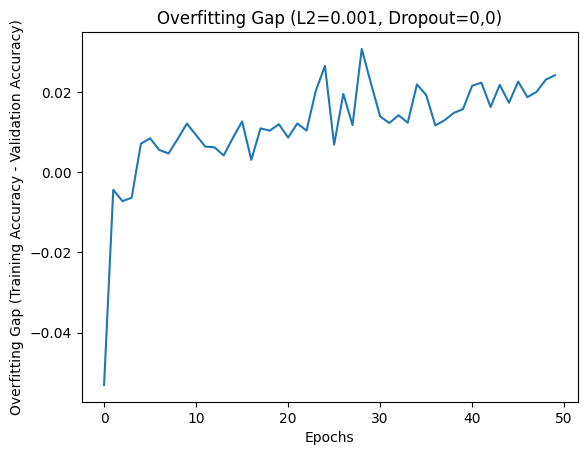

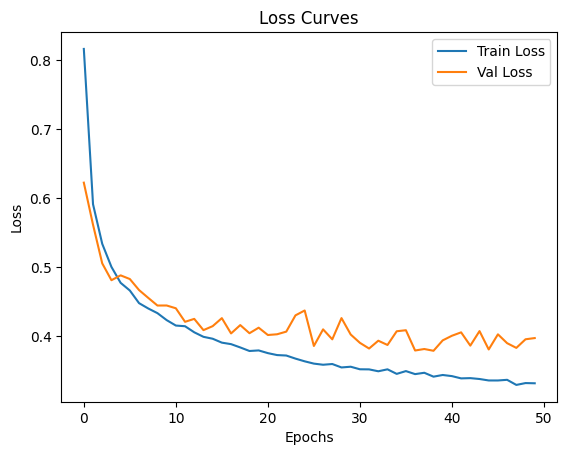

In [ ]:

l2_lambda=0.001
dropout_rate_1=0
dropout_rate_2=0

baseline_nn = build_nn(x_train_final.shape[1],False,l2_lambda,dropout_rate_1,dropout_rate_2)
history = baseline_nn.fit(x_train_final, y_train_final, validation_data=(x_val_final, y_val_final),
                          epochs=50, batch_size=128, verbose=2)
overfitting_gap(history, l2_lambda, dropout_rate_1, dropout_rate_2)
plot_loss_curves(history)


Epoch 1/50
383/383 - 7s - 19ms/step - accuracy: 0.7051 - loss: 0.8322 - val_accuracy: 0.8317 - val_loss: 0.4719
Epoch 2/50
383/383 - 4s - 12ms/step - accuracy: 0.8034 - loss: 0.5537 - val_accuracy: 0.8504 - val_loss: 0.4073
Epoch 3/50
383/383 - 4s - 10ms/step - accuracy: 0.8192 - loss: 0.4979 - val_accuracy: 0.8616 - val_loss: 0.3852
Epoch 4/50
383/383 - 3s - 7ms/step - accuracy: 0.8303 - loss: 0.4677 - val_accuracy: 0.8634 - val_loss: 0.3697
Epoch 5/50
383/383 - 2s - 6ms/step - accuracy: 0.8382 - loss: 0.4499 - val_accuracy: 0.8662 - val_loss: 0.3662
Epoch 6/50
383/383 - 4s - 10ms/step - accuracy: 0.8417 - loss: 0.4374 - val_accuracy: 0.8715 - val_loss: 0.3513
Epoch 7/50
383/383 - 2s - 6ms/step - accuracy: 0.8481 - loss: 0.4252 - val_accuracy: 0.8756 - val_loss: 0.3463
Epoch 8/50
383/383 - 2s - 6ms/step - accuracy: 0.8516 - loss: 0.4131 - val_accuracy: 0.8701 - val_loss: 0.3485
Epoch 9/50
383/383 - 2s - 6ms/step - accuracy: 0.8534 - loss: 0.4026 - val_accuracy: 0.8785 - val_loss: 0.33

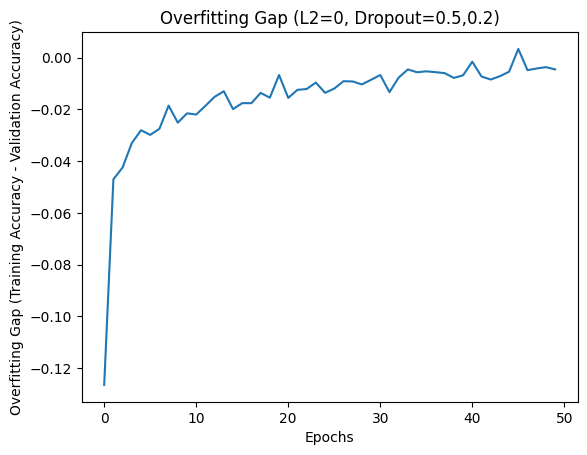

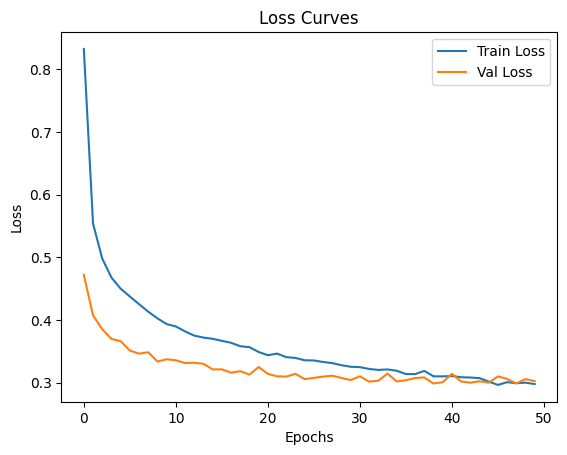

In [ ]:

l2_lambda=0
dropout_rate_1=0.50
dropout_rate_2=0.20

baseline_nn = build_nn(x_train_final.shape[1],False,l2_lambda,dropout_rate_1,dropout_rate_2)
history = baseline_nn.fit(x_train_final, y_train_final, validation_data=(x_val_final, y_val_final),
                          epochs=50, batch_size=128, verbose=2)
overfitting_gap(history, l2_lambda, dropout_rate_1, dropout_rate_2)
plot_loss_curves(history)


### 2.PCA-NN (L2 + Early Stopping)

In [ ]:

l2_lambda=0.001
dropout_rate_1=0.2
dropout_rate_2=0.5
pca_nn = build_nn(x_train_pca.shape[1],True,l2_lambda,dropout_rate_1,dropout_rate_2)  # Reuse same structure

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_pca_nn = pca_nn.fit(x_train_pca, y_train_final, validation_data=(x_val_pca, y_val_final),
                            epochs=50, batch_size=128, callbacks=[early_stop], verbose=2)

overfitting_gap(history_pca_nn, l2_lambda, dropout_rate_1, dropout_rate_2)
plot_loss_curves(history_pca_nn)
plot_loss_curves(history)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


383/383 - 5s - 13ms/step - accuracy: 0.7130 - loss: 1.0304 - val_accuracy: 0.8461 - val_loss: 0.5861
Epoch 2/50
383/383 - 3s - 7ms/step - accuracy: 0.8264 - loss: 0.6466 - val_accuracy: 0.8612 - val_loss: 0.5112
Epoch 3/50
383/383 - 4s - 11ms/step - accuracy: 0.8416 - loss: 0.5768 - val_accuracy: 0.8682 - val_loss: 0.4725
Epoch 4/50
383/383 - 3s - 7ms/step - accuracy: 0.8508 - loss: 0.5396 - val_accuracy: 0.8730 - val_loss: 0.4487
Epoch 5/50
383/383 - 3s - 8ms/step - accuracy: 0.8566 - loss: 0.5147 - val_accuracy: 0.8763 - val_loss: 0.4329
Epoch 6/50
383/383 - 2s - 5ms/step - accuracy: 0.8608 - loss: 0.4969 - val_accuracy: 0.8809 - val_loss: 0.4225
Epoch 7/50
383/383 - 2s - 6ms/step - accuracy: 0.8646 - loss: 0.4836 - val_accuracy: 0.8836 - val_loss: 0.4111
Epoch 8/50
383/383 - 2s - 6ms/step - accuracy: 0.8677 - loss: 0.4745 - val_accuracy: 0.8838 - val_loss: 0.4066
Epoch 9/50
383/383 - 3s - 7ms/step - accuracy: 0.8708 - loss: 0.4628 - val_accuracy: 0.8860 - val_loss: 0.4026
Epoch 10/5

### 3.Logistic Regression (L1, L2, ElasticNet)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

def evaluate_model_performance(model, history, x_train, y_train, x_val, y_val):
    # Predict class labels
    train_preds = np.argmax(model.predict(x_train, verbose=0), axis=1)
    val_preds = np.argmax(model.predict(x_val, verbose=0), axis=1)

    # Compute accuracies
    train_accuracy = accuracy_score(y_train, train_preds)
    val_accuracy = accuracy_score(y_val, val_preds)

    # Compute overfitting gap
    overfitting_gap_final = train_accuracy - val_accuracy

    print(f"\nFinal Train Accuracy: {train_accuracy:.4f}")
    print(f"Final Validation Accuracy: {val_accuracy:.4f}")
    print(f"Final Overfitting Gap: {overfitting_gap_final:.4f}")

    # Plot Loss Curves
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(14, 5))

    # Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Overfitting Gap per Epoch (Training acc - Validation acc)
    train_acc_per_epoch = history.history['accuracy']
    val_acc_per_epoch = history.history['val_accuracy']
    overfitting_gap_per_epoch = np.array(train_acc_per_epoch) - np.array(val_acc_per_epoch)

    plt.subplot(1, 2, 2)
    plt.plot(overfitting_gap_per_epoch, color='red', label='Overfitting Gap')
    plt.title('Overfitting Gap Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Gap (Train Acc - Val Acc)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return train_accuracy, val_accuracy, overfitting_gap_final


L1 (Lasso) - Train Accuracy: 0.8641, Validation Accuracy: 0.8586, Overfitting Gap: 0.0055
L2 (Ridge) - Train Accuracy: 0.8645, Validation Accuracy: 0.8591, Overfitting Gap: 0.0054
ElasticNet - Train Accuracy: 0.8645, Validation Accuracy: 0.8588, Overfitting Gap: 0.0057


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:

logreg_l1 = LogisticRegression(penalty='l1', solver='saga', max_iter=1000)
logreg_l1.fit(x_train_pca, y_train_final)


# Calculate overfitting gap for L1, L2, and ElasticNet models
train_acc_l1, val_acc_l1, overfitting_gap_l1 = evaluate_model_performance(logreg_l1, x_train_pca, y_train_final, x_val_pca, y_val_final)

# Print results
print(f"L1 (Lasso) - Train Accuracy: {train_acc_l1:.4f}, Validation Accuracy: {val_acc_l1:.4f}, Overfitting Gap: {overfitting_gap_l1:.4f}")


In [ ]:

logreg_l2 = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)
logreg_l2.fit(x_train_pca, y_train_final)

train_acc_l2, val_acc_l2, overfitting_gap_l2 = evaluate_model_performance(logreg_l2, x_train_pca, y_train_final, x_val_pca, y_val_final)

print(f"L2 (Ridge) - Train Accuracy: {train_acc_l2:.4f}, Validation Accuracy: {val_acc_l2:.4f}, Overfitting Gap: {overfitting_gap_l2:.4f}")


In [ ]:

logreg_en = LogisticRegression(penalty='elasticnet', l1_ratio=0.1, solver='saga', max_iter=1000)
logreg_en.fit(x_train_pca, y_train_final)

train_acc_en, val_acc_en, overfitting_gap_en = evaluate_model_performance(logreg_en, x_train_pca, y_train_final, x_val_pca, y_val_final)

print(f"ElasticNet - Train Accuracy: {train_acc_en:.4f}, Validation Accuracy: {val_acc_en:.4f}, Overfitting Gap: {overfitting_gap_en:.4f}")


### 4. SVM (RBF kernel)

In [ ]:
svm_01 = SVC(kernel='rbf', C=0.1).fit(x_train_pca, y_train_final)

acc_train_01, acc_val_01, gap_01 = evaluate_model_performance(svm_01, x_train_pca, y_train_final, x_val_pca, y_val_final)

print(f"SVM C=0.1 - Train: {acc_train_01:.4f}, Val: {acc_val_01:.4f}, Gap: {gap_01:.4f}")


In [ ]:
svm_1 = SVC(kernel='rbf', C=1).fit(x_train_pca, y_train_final)

acc_train_1, acc_val_1, gap_1 = evaluate_model_performance(svm_1, x_train_pca, y_train_final, x_val_pca, y_val_final)

print(f"SVM C=1   - Train: {acc_train_1:.4f}, Val: {acc_val_1:.4f}, Gap: {gap_1:.4f}")


In [ ]:
svm_10 = SVC(kernel='rbf', C=10).fit(x_train_pca, y_train_final)

acc_train_10, acc_val_10, gap_10 = evaluate_model_performance(svm_10, x_train_pca, y_train_final, x_val_pca, y_val_final)

print(f"SVM C=10  - Train: {acc_train_10:.4f}, Val: {acc_val_10:.4f}, Gap: {gap_10:.4f}")

### 5. Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=5, random_state=42)
rf.fit(x_train_pca, y_train_final)

acc_train_rf, acc_val_rf, gap_rf = evaluate_model_performance(rf, x_train_pca, y_train_final, x_val_pca, y_val_final)

print(f"Random Forest - Train Accuracy: {acc_train_rf:.4f}, Val Accuracy: {acc_val_rf:.4f}, Overfitting Gap: {gap_rf:.4f}")


RandomForestClassifier(max_depth=15, min_samples_split=5, random_state=42)

### 6. Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
gb.fit(x_train_pca, y_train_final)

acc_train_gb, acc_val_gb, gap_gb = evaluate_model_performance(gb, x_train_pca, y_train_final, x_val_pca, y_val_final)

print(f"Gradient Boosting - Train Accuracy: {acc_train_gb:.4f}, Val Accuracy: {acc_val_gb:.4f}, Overfitting Gap: {gap_gb:.4f}")


### Evaluation Function

In [ ]:
def evaluate_model(model, x_val, y_val, name="Model"):
    y_pred = model.predict(x_val)
    if hasattr(model, "predict_proba"):
        print(f"\n{name} Accuracy:", accuracy_score(y_val, y_pred))
    else:
        y_pred = np.argmax(y_pred, axis=1)
        print(f"\n{name} Accuracy:", accuracy_score(y_val, y_pred))
    print(classification_report(y_val, y_pred))


### Evaluate All Models

In [ ]:
evaluate_model(baseline_nn, x_val_pca, y_val_final, "Baseline NN")
evaluate_model(pca_nn, x_val_pca, y_val_final, "PCA NN")
evaluate_model(logreg_l1, x_val_pca, y_val_final, "LogReg L1")
evaluate_model(logreg_l2, x_val_pca, y_val_final, "LogReg L2")
evaluate_model(logreg_en, x_val_pca, y_val_final, "LogReg ElasticNet")
evaluate_model(svm_01, x_val_pca, y_val_final, "SVM C=0.1")
evaluate_model(svm_1, x_val_pca, y_val_final, "SVM C=1")
evaluate_model(svm_10, x_val_pca, y_val_final, "SVM C=10")
evaluate_model(rf, x_val_pca, y_val_final, "Random Forest")
evaluate_model(gb, x_val_pca, y_val_final, "Gradient Boosting")
